In [27]:
from HH_case_partition_MCMC import *

plt.style.use('ggplot')

In [6]:
def GenerateSyntheticData(N,beta,hh_size_dist):
    m = len(hh_size_dist) #max hh size
    max_k = int(0.5*m*(m+3))
    
    hh_size_dist_adjusted = np.array([i*p for i,p in enumerate(hh_size_dist,1)])
    hh_size_dist_adjusted = hh_size_dist_adjusted/sum(hh_size_dist_adjusted)
    
    household_sizes = np.random.choice(np.arange(1,m+1,1),p = hh_size_dist_adjusted,size=N)
    household_size_counts = [sum(np.where(household_sizes == n,1,0)) for n in range(1,m+1)]
    C = np.zeros(max_k)
    for n in range(1,m+1):
        fs_P = final_size_distribution_homogeneous_no_intro(n, 1, beta/n, lambda t: np.exp(-t))
        final_sizes = np.random.choice(np.arange(0,n+1,1),p=fs_P,size= household_size_counts[n-1])
        final_size_counts = [sum(np.where(final_sizes == k,1,0)) for k in range(0,n+1)]
        for k in range(0,n+1):
            index = IndexChange2dTo1d(n, k)
            C[index] += final_size_counts[k]
    return C

# Ball equations demo

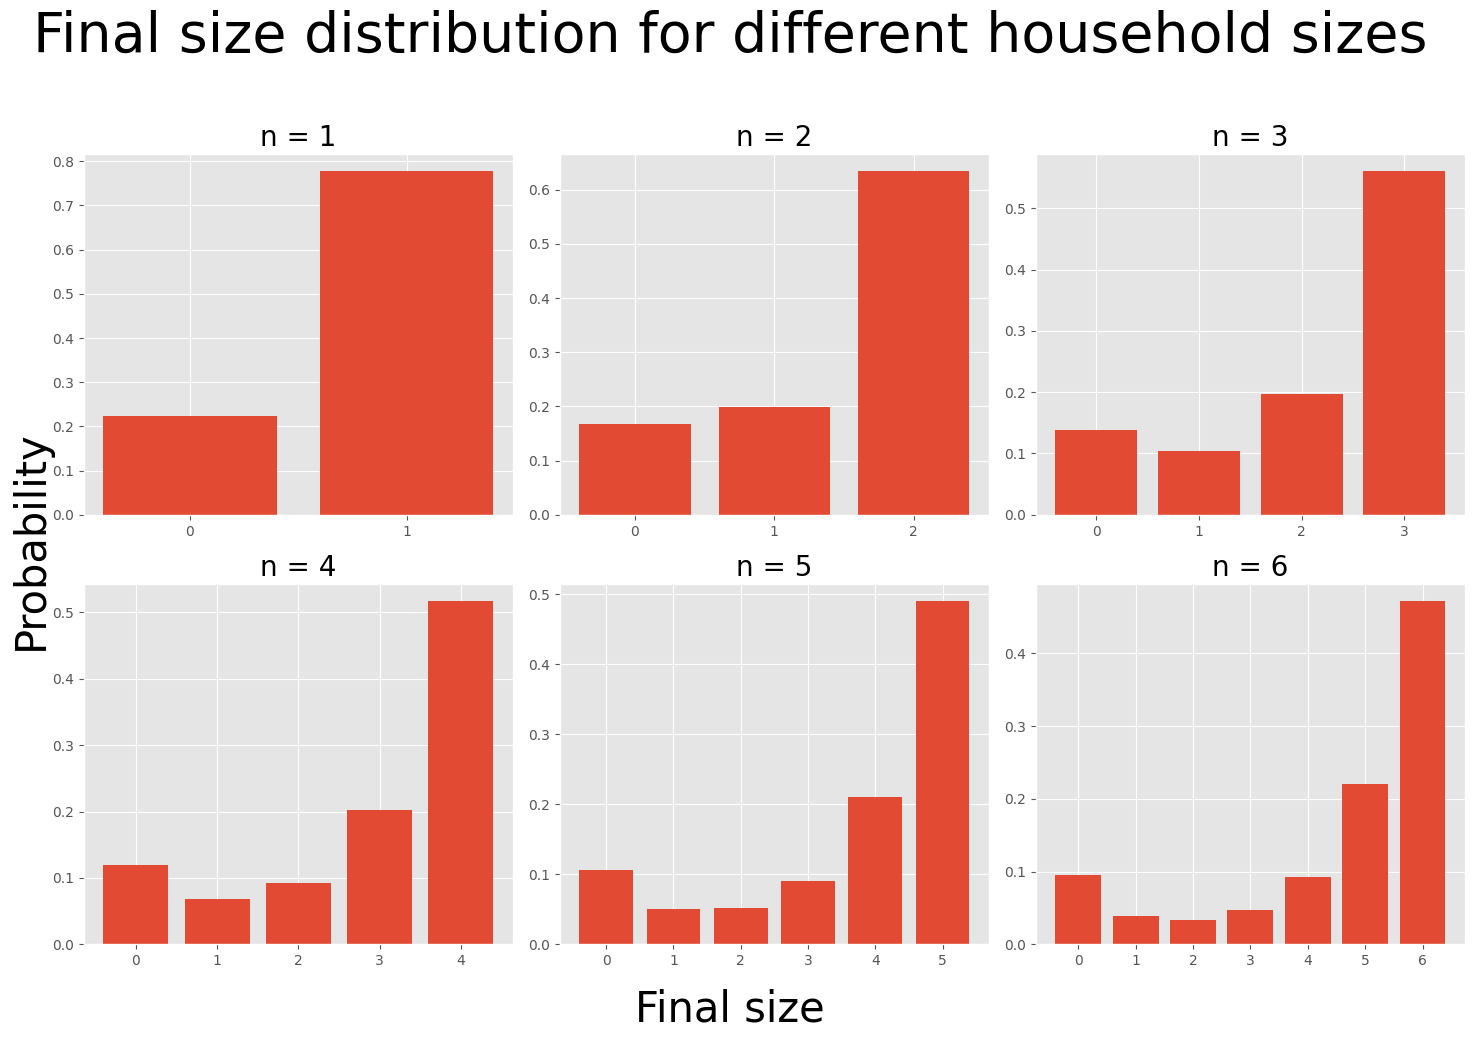

In [46]:
n_values = [1,2,3,4,5,6]
m = 1
phi = lambda t: np.exp(-t)
beta = 1.5

fs_P = {}

for n in n_values:
    fs_P[n] = final_size_distribution_homogeneous_no_intro(n, 1, beta/n**0.75, phi)

fig,axs = plt.subplots(2,3,figsize=(15,10))

for n in n_values:
    i = (n-1)//3
    j = (n-1)%3
    ax = axs[i,j]

    ax.bar(np.arange(0,n+1,1),fs_P[n])
    ax.set_title(f"n = {n}",fontsize=20)
    
    ax.set_xticks(np.arange(0,n+1,1))

fig.supxlabel("Final size",fontsize=30)
fig.supylabel("Probability",fontsize=30)
fig.suptitle("Final size distribution for different household sizes", fontsize=40, y=1.03)
plt.tight_layout()

In [11]:
3//3


1

# Test that starting point is forgotten

In [ ]:
def FlatPartition(n,y,N,m):
    C = np.zeros(int(0.5*m*(m+3)))
    
    hh_size_s = int(n//N)
    hh_size_l = hh_size_s + 1
    
    N_l = n-hh_size_s*N
    N_s = N - N_l
    
    cases_less = int(y//N)
    cases_more = cases_less+1
    N_more = y - N*cases_less
    N_less = N - N_more
    
    
    k_less_s = IndexChange2dTo1d(hh_size_s, cases_less)
    k_more_s = IndexChange2dTo1d(hh_size_s, cases_more)
    k_less_l = IndexChange2dTo1d(hh_size_l, cases_less)
    k_more_l = IndexChange2dTo1d(hh_size_l, cases_more)
    if N_less<=N_s:
        C[k_less_s] = N_less
        if N_more<= N_s-N_less:
            C[k_more_s] = N_more
        else:
            C[k_more_s] = N_s-N_less
            C[k_more_l] = N_more - C[k_more_s]
    else:
        C[k_less_s] = N_s
        C[k_less_l] = N_less- N_s
        C[k_more_l] = N_more
    return C

def SplitPartition(n,y,N,m):
    C = np.zeros(int(0.5*m*(m+3)))
    max_k =len(C)
    
    N_m = int(np.floor((n-N)/(m-1)))
    N_1 = int(N-np.ceil((n-N)/(m-1)))
    last_size = N-N_m-N_1
    
    if y<N_1:
        C[0] = N_1-y
        C[1] = y
        C[IndexChange2dTo1d(last_size, 0)] = 1
        C[IndexChange2dTo1d(m, 0)] = N_m
    else:
        C[1] = N_1
        y -= N_1
        if y< m*N_m:
            C[IndexChange2dTo1d(last_size, 0)] = 1
            C[IndexChange2dTo1d(m, m)] = y//m

            if y%m ==0:
                C[IndexChange2dTo1d(m, 0)] = N_m - y//m
            else:
                C[IndexChange2dTo1d(m, int(y%m))] = 1
                C[IndexChange2dTo1d(m, 0)] =  N_m - y//m - 1
        else:
            C[IndexChange2dTo1d(m, m)] = N_m
            y-= N_m*m
            C[IndexChange2dTo1d(last_size, y)] = 1
            
            
        return C

In [13]:
beta_values = [0.1,0.5,0.75,1,1.5,2]

m=4
actual_hh_dist = np.array([0.35,0.15,0.13,0.06])
actual_hh_dist = actual_hh_dist/sum(actual_hh_dist)
weighted_actual_hh_dist = np.array([i*p for i,p in enumerate(actual_hh_dist,2)])
weighted_actual_hh_dist = weighted_actual_hh_dist/sum(weighted_actual_hh_dist)
print("actual_hh_dist",actual_hh_dist)
print("weighted_actual_hh_dist",weighted_actual_hh_dist)

actual_hh_dist [0.50724638 0.2173913  0.1884058  0.08695652]
weighted_actual_hh_dist [0.35532995 0.2284264  0.26395939 0.15228426]
